# In-Situ Concrete Strength Evaluation (ACI 228.1R Concept)
**Developed by:** Ali Abdulameer (Ali4Concrete) | Computational Civil Engineer  
**Purpose:** Convert Non-Destructive Testing (NDT) readings into SAFE concrete strength predictions without writing any complex code.

## How to use this tool:
As a Civil Engineer, you only need to do **ONE** thing:
1. Go to **STEP 1** below.
2. Replace the numbers in the `NDT_Readings_X` list with your actual site readings (e.g., UPV in km/s).
3. Replace the numbers in the `Core_Strength_Y` list with your actual laboratory core test results (in MPa).
4. Run all cells. The code will do the math, plot the charts, and give you the safe engineering prediction.

**Engineering Logic:** We do not just calculate the "Expected Strength" (Average). Following safety concepts, we calculate the **Lower Confidence Limit (LCL)**. This ensures that the strength we rely on for decision-making (like removing formwork) is statistically safe, accounting for testing errors (RMSE).

In [7]:
# ==========================================
# IMPORTING TOOLS (DO NOT CHANGE THIS CELL)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Setting up the visual style for clear engineering reports
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Engineering Tools Loaded Successfully. Please proceed to STEP 1.")

✅ Engineering Tools Loaded Successfully. Please proceed to STEP 1.


In [8]:
# ==========================================
# STEP 1: ENTER YOUR DATA HERE
# ==========================================

# X: NDT Readings (e.g., UPV in km/s)
NDT_Readings_X = [3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7]

# Y: Core Strengths (in MPa)
Core_Strength_Y = [18.5, 21.0, 22.5, 24.0, 26.5, 29.0, 31.5, 33.0, 35.5, 38.0, 41.0]

# --- Professional Validation Check ---
if len(NDT_Readings_X) < 6:
    print("⚠️ WARNING: ACI 228.1R recommends at least 6-10 data pairs for a reliable correlation.")
else:
    print(f"✅ Data verified: {len(NDT_Readings_X)} points ready for analysis.")

✅ Data verified: 11 points ready for analysis.


In [9]:
# ==========================================
# STEP 2: MATHEMATICAL ANALYSIS (DO NOT CHANGE)
# ==========================================
# Convert lists to arrays for calculation
x = np.array(NDT_Readings_X)
y = np.array(Core_Strength_Y)

# 1. Build the Mathematical Model (Linear Fit: y = mx + c)
slope, intercept = np.polyfit(x, y, 1)
y_expected = slope * x + intercept

# 2. Calculate Engineering Error Metrics
r2 = r2_score(y, y_expected)
rmse = np.sqrt(mean_squared_error(y, y_expected))

# 3. Calculate the Safe Engineering Strength (Lower Confidence Limit)
# Using a simplified 90% confidence concept (Z-score approx 1.28 * RMSE)
safety_margin = 1.28 * rmse
y_safe = y_expected - safety_margin

print("📊 --- MODEL PERFORMANCE REPORT ---")
print(f"Equation: Strength = ({slope:.2f} * NDT) + ({intercept:.2f})")
print(f"Correlation (R-Squared): {r2:.2f} (1.0 is perfect)")
print(f"Average Error (RMSE):    ±{rmse:.2f} MPa")
print(f"Safety Penalty Applied:  -{safety_margin:.2f} MPa")
print("-----------------------------------")

📊 --- MODEL PERFORMANCE REPORT ---
Equation: Strength = (22.05 * NDT) + (-63.45)
Correlation (R-Squared): 1.00 (1.0 is perfect)
Average Error (RMSE):    ±0.47 MPa
Safety Penalty Applied:  -0.60 MPa
-----------------------------------


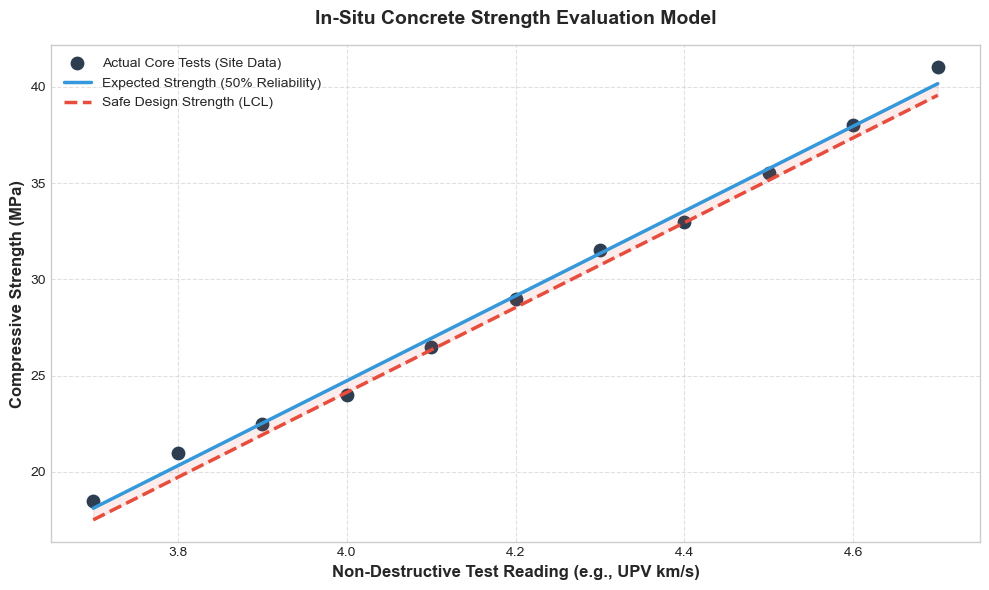

In [10]:
# ==========================================
# STEP 3: VISUAL REPORT (DO NOT CHANGE)
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)

# Plot actual site data
plt.scatter(x, y, color='#2c3e50', s=80, label='Actual Core Tests (Site Data)')

# Plot Expected Strength (The Average Trend)
plt.plot(x, y_expected, color='#3498db', linewidth=2.5, label='Expected Strength (50% Reliability)')

# Plot Safe Strength (The Lower Limit for Design/Safety)
plt.plot(x, y_safe, color='#e74c3c', linewidth=2.5, linestyle='--', label=f'Safe Design Strength (LCL)')

# Shade the area between expected and safe
plt.fill_between(x, y_safe, y_expected, color='#e74c3c', alpha=0.1)

# Formatting the Chart
plt.title('In-Situ Concrete Strength Evaluation Model', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Non-Destructive Test Reading (e.g., UPV km/s)', fontsize=12, fontweight='bold')
plt.ylabel('Compressive Strength (MPa)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# STEP 4: PREDICT NEW LOCATIONS
# ==========================================
# Instructions: You tested a new column. The UPV reading is 4.35. 
# Type 4.35 below, and the code will tell you if the column is safe.

NEW_NDT_READING = 4.35  # <--- Type your new site reading here

# --- The Calculation ---
expected_strength = slope * NEW_NDT_READING + intercept
safe_strength = expected_strength - safety_margin

print(f"🏢 For a new NDT reading of [{NEW_NDT_READING}]:")
print(f"➤ Expected Strength: {expected_strength:.1f} MPa")
print(f"➤ SAFE ENGINEERING STRENGTH (Use this for decisions): {safe_strength:.1f} MPa")

🏢 For a new NDT reading of [4.35]:
➤ Expected Strength: 32.4 MPa
➤ SAFE ENGINEERING STRENGTH (Use this for decisions): 31.8 MPa


# ⚠️ Legal Disclaimer & Engineering Notice
**Project:** In-Situ Concrete Strength Evaluation Tool  
**Author:** Ali Abdulameer (Ali4Concrete)

### 🛑 Disclaimer:
This tool is provided for **educational and preliminary estimation purposes only**. 
1. The results generated by this script should **NOT** be used as the sole basis for critical structural decisions (such as removing shores, post-tensioning, or loading structures) without a formal review by a licensed Structural Engineer.
2. The accuracy of the prediction depends entirely on the quality of the input data (NDT-Core pairs).
3. The author assumes no liability for any structural failure, financial loss, or legal consequences resulting from the use of this code.

---

### 🛠️ Professional Analysis of the Tool

#### ✅ Advantages (Pros):
* **Safety-First Approach:** Unlike standard Excel sheets, this tool calculates the **Lower Confidence Limit (LCL)**, providing a conservative "Safe Strength" rather than just a risky average.
* **Statistical Integrity:** Automatically calculates **RMSE** (Root Mean Square Error) to quantify the reliability of your site testing.
* **Zero-Code Entry:** Designed for Civil Engineers; just plug in the data and run.
* **Visual Reporting:** Generates a professional chart that can be included in quality control reports to justify site decisions.

#### ❌ Limitations (Cons):
* **Data Dependency:** Requires at least 6 to 10 "NDT-Core" pairs to be statistically valid according to ACI 228.1R.
* **Material Sensitivity:** The model is specific to the concrete mix tested. You cannot use a model developed for "Project A" to predict strength in "Project B" if the mix design is different.
* **Linear Assumption:** This specific version uses a Linear Regression. For very high-strength concrete or complex admixtures, a Power or Exponential function might be required.